In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv('/Users/macbook/Documents/2Nam3/TimeSeries/Data/PJME_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')

## EDA & THIẾT LẬP DATETIME INDEX

In [3]:
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [4]:
if 'Datetime' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df.set_index('Datetime', inplace=True)

In [5]:
if df['PJME_MW'].isnull().sum() > 0:
    print(f"Phát hiện {df['PJME_MW'].isnull().sum()} giá trị thiếu. Đang nội suy...")
    df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

In [43]:
df_clean

,PJME_MW,hour,dayofweek,month,residuals
Datetime,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,775.989948
2002-01-01 02:00:00,29265.0,2,1,1,-552.882584
2002-01-01 03:00:00,28357.0,3,1,1,-412.330312
2002-01-01 04:00:00,27899.0,4,1,1,-166.321492
2002-01-01 05:00:00,28057.0,5,1,1,37.640435
...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,8,775.386726
2018-08-02 21:00:00,43256.0,21,3,8,1673.751701
2018-08-02 22:00:00,41552.0,22,3,8,89.276303


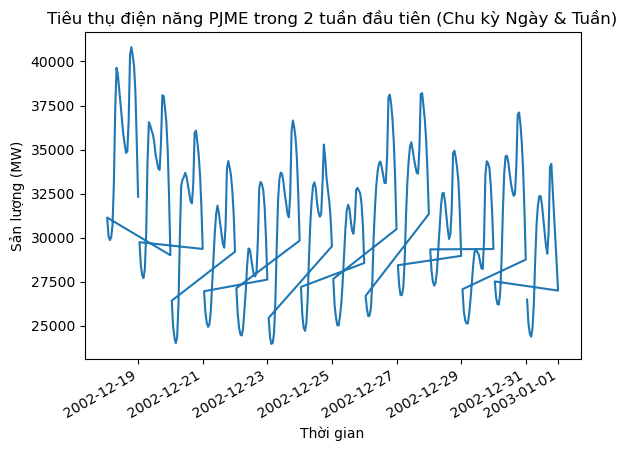

In [6]:
# Vẽ đồ thị 2 tuần đầu tiên để quan sát chu kỳ ngày/tuần trực quan
df['PJME_MW'].iloc[:24*14].plot(title="Tiêu thụ điện năng PJME trong 2 tuần đầu tiên (Chu kỳ Ngày & Tuần)")
plt.ylabel("Sản lượng (MW)")
plt.xlabel("Thời gian")
plt.show()

Dữ liệu thô rất nhiễu: Chu kỳ ngày và tuần đan xen dày đặc. Nếu dùng mô hình ARIMA đơn giản, nó sẽ không "thấy" được sự lặp lại của chu kỳ tuần, vì nó chỉ nhìn thấy các đỉnh cao thấp không đều.

Cần biến ngoại sinh: Các đỉnh cao thấp không đều ở biểu đồ chính là lý do chúng ta cần các biến ngoại sinh (hour, dayofweek). Biến hour sẽ giúp mô hình giải thích được tại sao tại cùng một ngày, giờ thấp điểm lại khác giờ cao điểm. Biến dayofweek sẽ giúp giải thích tại sao cùng một giờ nhưng ngày thường lại khác ngày cuối tuần.

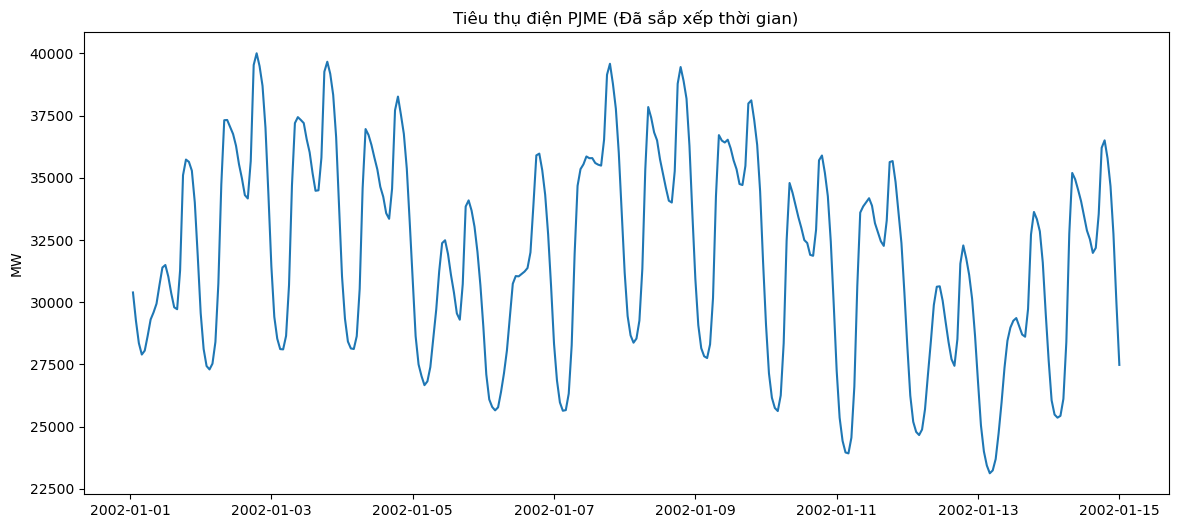

In [7]:
# Sắp xếp lại dữ liệu theo thời gian (cực kỳ quan trọng)
df_plot = df.sort_index().iloc[:24*14]

# Vẽ lại
plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot['PJME_MW'])
plt.title("Tiêu thụ điện PJME (Đã sắp xếp thời gian)")
plt.ylabel("MW")
plt.show()

Tính dừng (Stationarity): Nhìn bằng mắt thường, chuỗi này dao động quanh một mức trung bình nhất định (không có xu hướng tăng vọt hay giảm sâu dài hạn trong 2 tuần này). Tuy nhiên, phương sai của các đỉnh đang thay đổi. Đây là bằng chứng cho thấy dữ liệu có hiệu ứng ARCH (phương sai không ổn định), củng cố lý do tại sao dùng GARCH là cực kỳ hợp lý.

Cần biến ngoại sinh (Exogenous Variables): Các đỉnh cao/thấp không đồng đều chính là lý do mô hình cần các biến hour, dayofweek để "giải thích" tại sao đỉnh ngày này khác đỉnh ngày kia. Nếu không có các biến này, ARIMA sẽ bị "bối rối" khi cố gắng đoán xem đỉnh tiếp theo sẽ cao bao nhiêu.

Dữ liệu nhiễu (Noise): Có những đoạn sóng hơi "răng cưa". Đây là nhiễu trắng. ARIMAX sẽ xử lý phần xu hướng/chu kỳ, và GARCH sẽ xử lý phần "độ rộng của răng cưa" này.

## XỬ LÝ ĐA CHU KỲ (TẠO BIẾN NGOẠI SINH)

In [8]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

In [9]:
exog_cols = ['hour', 'dayofweek', 'month']
X_exog = pd.get_dummies(df[exog_cols], columns=exog_cols, drop_first=True)

In [10]:
X_exog = X_exog.astype(float)

In [11]:
print(df.head())
print("\nKích thước ma trận biến ngoại sinh:", X_exog.shape)

                     PJME_MW  hour  dayofweek  month
Datetime                                            
2002-12-31 01:00:00  26498.0     1          1     12
2002-12-31 02:00:00  25147.0     2          1     12
2002-12-31 03:00:00  24574.0     3          1     12
2002-12-31 04:00:00  24393.0     4          1     12
2002-12-31 05:00:00  24860.0     5          1     12

Kích thước ma trận biến ngoại sinh: (145366, 40)


In [12]:
df

,PJME_MW,hour,dayofweek,month
Datetime,,,,
2002-12-31 01:00:00,26498.0,1,1,12
2002-12-31 02:00:00,25147.0,2,1,12
2002-12-31 03:00:00,24574.0,3,1,12
2002-12-31 04:00:00,24393.0,4,1,12
2002-12-31 05:00:00,24860.0,5,1,12
...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1
2018-01-01 21:00:00,43751.0,21,0,1
2018-01-01 22:00:00,42402.0,22,0,1


In [13]:
X_exog

,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-12-31 01:00:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2002-12-31 02:00:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2002-12-31 03:00:00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2002-12-31 04:00:00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2002-12-31 05:00:00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Kiểm định Tính dừng

In [14]:
from statsmodels.tsa.stattools import adfuller

# 1. Chạy kiểm định ADF
# autolag='AIC' giúp tự động chọn độ trễ tối ưu dựa trên tiêu chuẩn AIC
adf_result = adfuller(df['PJME_MW'].dropna(), autolag='AIC')

print(f"--- Kết quả kiểm định ADF ---")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical Values: {adf_result[4]}")

# 2. Đánh giá kết quả
if adf_result[1] < 0.05:
    print("\nKết luận: p-value < 0.05. Dữ liệu đã dừng (Stationary).")
    print("Bạn có thể tiến thẳng đến Bước 4 (Dò tham số ARIMA).")
    is_stationary = True
else:
    print("\nKết luận: p-value >= 0.05. Dữ liệu CHƯA dừng.")
    print("Cần thực hiện lấy sai phân (Differencing) để loại bỏ xu hướng.")
    is_stationary = False

--- Kết quả kiểm định ADF ---
ADF Statistic: -18.8289
p-value: 0.0000
Critical Values: {'1%': -3.430395009088914, '5%': -2.861559893380481, '10%': -2.5667805885384065}

Kết luận: p-value < 0.05. Dữ liệu đã dừng (Stationary).
Bạn có thể tiến thẳng đến Bước 4 (Dò tham số ARIMA).


In [32]:
# 2. Tổ chức lại dữ liệu thành một Dictionary
adf_data = {
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Critical Value (1%)",
        "Critical Value (5%)",
        "Critical Value (10%)"
    ],
    "Value": [
        adf_result[0],                  # ADF Statistic
        adf_result[1],                  # p-value
        adf_result[4]['1%'],            # Critical Value 1%
        adf_result[4]['5%'],            # Critical Value 5%
        adf_result[4]['10%']            # Critical Value 10%
    ]
}

# 3. Chuyển thành DataFrame để hiển thị dạng bảng có khung chỉn chu
df_output = pd.DataFrame(adf_data)

# Thiết lập tiêu đề bảng (Optional)
print("ADF Test on Closing Prices (After First Order Differencing):")
print("-" * 60)

# Gọi trực tiếp tên biến trong Jupyter để hiển thị bảng HTML đẹp mắt
df_output

ADF Test on Closing Prices (After First Order Differencing):
------------------------------------------------------------


,Metric,Value
0,ADF Statistic,-1.882891e+01
1,p-value,2.022125e-30
2,Critical Value (1%),-3.430395e+00
3,Critical Value (5%),-2.861560e+00
4,Critical Value (10%),-2.566781e+00


## Dò tìm tham số tối ưu (ARIMAX)

In [15]:
import pmdarima as pm

print("--- Đang dò tìm tham số mô hình ARIMAX... ---")

# Dùng auto_arima với biến ngoại sinh X_exog (đã tạo ở Bước 2)
# seasonal=False: Vì biến X_exog (giờ, ngày, tháng) đã nắm bắt tính mùa vụ rồi
model = pm.auto_arima(df['PJME_MW'], 
                      exogenous=X_exog,
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True, 
                      error_action="ignore",
                      trace=True)

print(model.summary())

# --- THU VỀ PHẦN DƯ (RESIDUALS) ---
# Đây là bước cực kỳ quan trọng để chuẩn bị cho GARCH
residuals = model.resid()

# Lưu residuals vào df để phục vụ kiểm định ARCH sau này
df['residuals'] = residuals

print("\nĐã tách thành công phần dư (residuals).")

--- Đang dò tìm tham số mô hình ARIMAX... ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2428594.393, Time=133.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2553151.721, Time=1.78 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2451250.128, Time=5.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2484131.097, Time=29.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2553149.721, Time=0.84 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2449963.896, Time=18.80 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2430562.574, Time=87.21 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2430068.327, Time=145.72 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2427465.368, Time=168.75 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2449663.272, Time=41.30 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2421178.887, Time=190.57 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=2421904.273, Time=204.22 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=2421036.810, Time=227.13 se

In [ ]:
print(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:               145366
Model:               SARIMAX(2, 1, 5)   Log Likelihood            -1209977.879
Date:                Wed, 27 May 2026   AIC                        2419971.757
Time:                        21:56:51   BIC                        2420050.853
Sample:                             0   HQIC                       2419995.364
                             - 145366                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.8897      0.001   1669.191      0.000       1.887       1.892
ar.L2         -0.9533      0.001   -910.880      0.000      -0.955      -0.951
ma.L1         -1.3492      0.002   -736.187      0.000      -1.353      -1.346
ma.L2          0.1480      0.003     42.927      0.000       0.141       0.155
ma.L3          0.0729      0.006     12.211      0.000       0.061       0.085
ma.L4          0.0891      0.006     14.167      0.000       0.077       0.101
ma.L5          0.0758      0.004     21.029      0.000       0.069       0.083
sigma2       9.94e+05   1676.282    592.972      0.000    9.91e+05    9.97e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.36   Jarque-Bera (JB):            811879.48
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
residuals

Datetime
2002-12-31 01:00:00    26498.000000
2002-12-31 02:00:00   -14618.022079
2002-12-31 03:00:00     1459.868774
2002-12-31 04:00:00     1464.118934
2002-12-31 05:00:00     1480.742042
                           ...     
2018-01-01 20:00:00      -24.227703
2018-01-01 21:00:00     -261.296926
2018-01-01 22:00:00     -857.877744
2018-01-01 23:00:00    -1294.572404
2018-01-02 00:00:00      -93.965179
Length: 145366, dtype: float64

In [17]:
model

,order,"(2, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:               145366
Model:               SARIMAX(2, 1, 5)   Log Likelihood            -1209977.879
Date:                Mon, 25 May 2026   AIC                        2419971.757
Time:                        21:27:07   BIC                        2420050.853
Sample:                             0   HQIC                       2419995.364
                             - 145366                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.8897      0.001   1669.191      0.000       1.887       1.892
ar.L2         -0.9533      0.001   -910.880      0.000      -0.955      -0.951
ma.L1         -1.3492      0.002   -736.187      0.000      -1.353      -1.346
ma.L2          0.1480      0.003     42.927      0.000       0.141       0.155
ma.L3          0.0729      0.006     12.211      0.000       0.061       0.085
ma.L4          0.0891      0.006     14.167      0.000       0.077       0.101
ma.L5          0.0758      0.004     21.029      0.000       0.069       0.083
sigma2       9.94e+05   1676.282    592.972      0.000    9.91e+05    9.97e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.36   Jarque-Bera (JB):            811879.48
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
from statsmodels.stats.diagnostic import het_arch

# Kiểm định ARCH-LM
arch_test = het_arch(residuals) # residuals là biến bạn đã lấy từ model.resid()
print(f"Lagrange Multiplier test p-value: {arch_test[1]:.4f}")

Lagrange Multiplier test p-value: 0.0000


In [21]:
from arch import arch_model

# 1. Khai báo mô hình GARCH(1,1)
# vol='Garch': dùng GARCH
# p=1, q=1: bậc của mô hình
# dist='Normal': giả định phần dư tuân theo phân phối chuẩn
model_garch = arch_model(residuals, vol='Garch', p=1, q=1, dist='Normal')

# 2. Fit mô hình
results_garch = model_garch.fit(disp='off')

# 3. Xem kết quả
print(results_garch.summary())

/opt/anaconda3/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.995e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:           -1.19679e+06
Distribution:                  Normal   AIC:                       2.39358e+06
Method:            Maximum Likelihood   BIC:                       2.39362e+06
                                        No. Observations:               145366
Date:                Mon, May 25 2026   Df Residuals:                   145365
Time:                        21:32:12   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            75.5941      9.789      7.722  1.145e-14 [ 56.407, 94.78

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


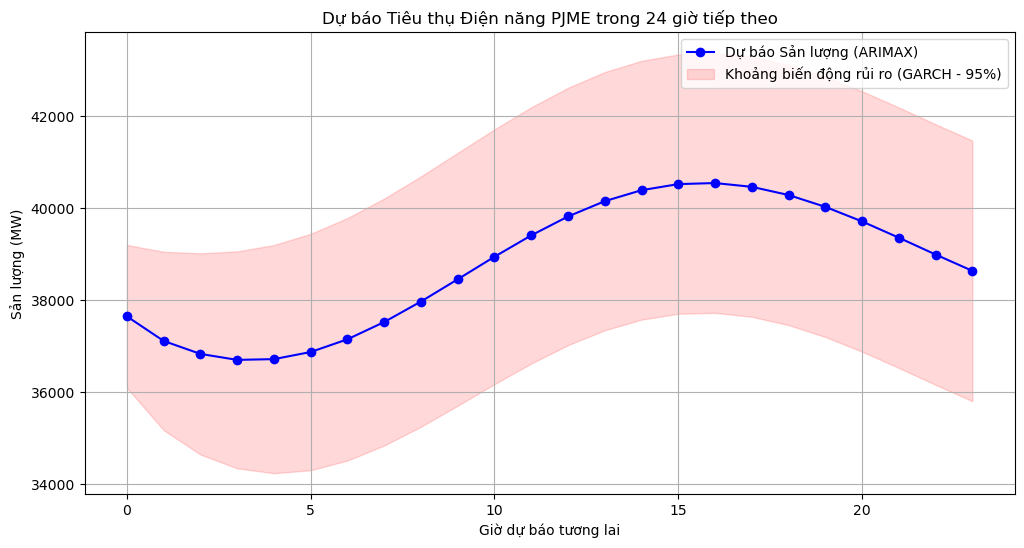

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Xác định số bước cần dự báo (ví dụ 24 giờ tiếp theo)
horizon = 24

# Cần chuẩn bị ma trận biến ngoại sinh cho 24 giờ tương lai (X_exog_forecast)
# Ở đây ta lấy tạm 24 dòng cuối của X_exog để làm ví dụ test nhanh
X_exog_forecast = X_exog.iloc[-horizon:] 

# 2. Dự báo Giá trị trung bình từ ARIMAX
arima_forecast = model.predict(n_periods=horizon, exogenous=X_exog_forecast)

# 3. Dự báo Phương sai (Volatility) từ GARCH
garch_forecast = results_garch.forecast(horizon=horizon)
# Lấy độ lệch chuẩn (Conditional Standard Deviation)
garch_stderr = np.sqrt(garch_forecast.variance.values[-1, :])

# 4. Tính toán Khoảng tin cậy động 95% (95% Dynamic Confidence Interval)
lower_bound = arima_forecast - 1.96 * garch_stderr
upper_bound = arima_forecast + 1.96 * garch_stderr

# 5. Vẽ đồ thị kết quả dự báo
plt.figure(figsize=(12, 6))
plt.plot(range(horizon), arima_forecast, label='Dự báo Sản lượng (ARIMAX)', color='blue', marker='o')
plt.fill_between(range(horizon), lower_bound, upper_bound, color='red', alpha=0.15, label='Khoảng biến động rủi ro (GARCH - 95%)')
plt.title(f"Dự báo Tiêu thụ Điện năng PJME trong {horizon} giờ tiếp theo")
plt.xlabel("Giờ dự báo tương lai")
plt.ylabel("Sản lượng (MW)")
plt.legend()
plt.grid(True)
plt.show()

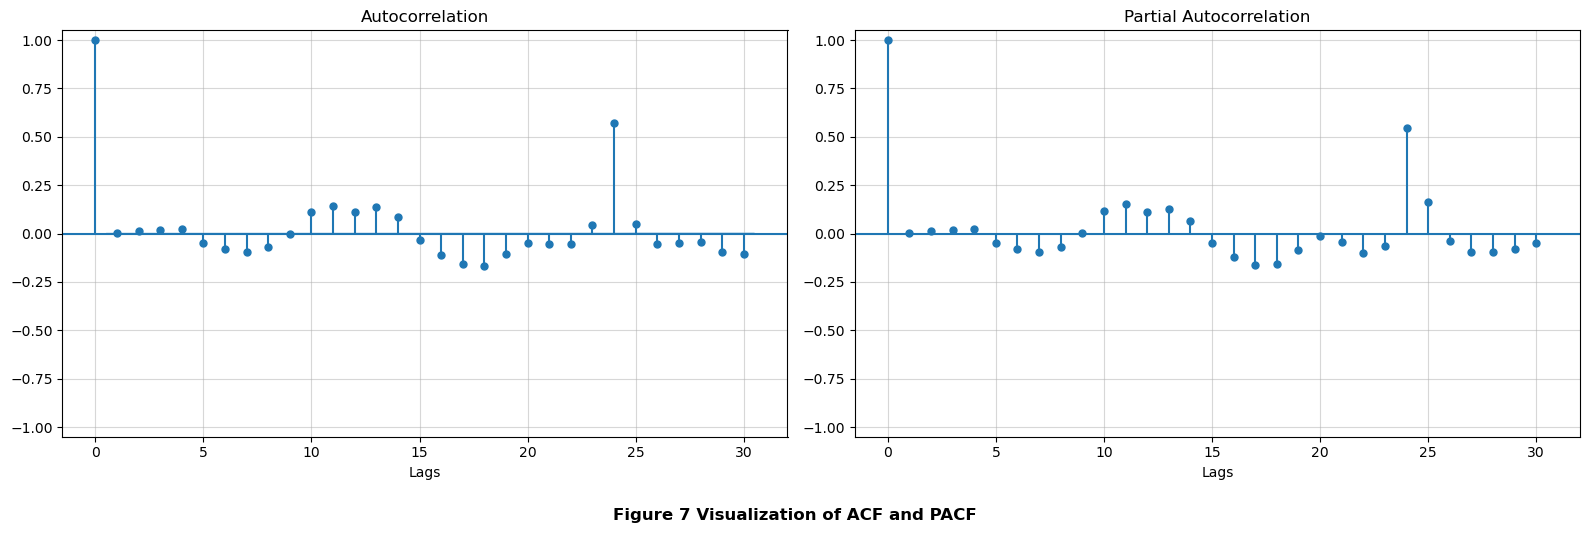

In [33]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Khởi tạo khung tranh gồm 1 hàng và 2 cột
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị cột bên trái: Autocorrelation (ACF)
plot_acf(df['residuals'].dropna(), ax=axes[0], lags=30, color='tab:blue', vlines_kwargs={"colors": 'tab:blue'})
axes[0].set_title('Autocorrelation', fontsize=12)
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_xlabel('Lags')
axes[0].grid(True, alpha=0.5)

# Đồ thị cột bên phải: Partial Autocorrelation (PACF)
plot_pacf(df['residuals'].dropna(), ax=axes[1], lags=30, color='tab:blue', vlines_kwargs={"colors": 'tab:blue'}, method='ywm')
axes[1].set_title('Partial Autocorrelation', fontsize=12)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_xlabel('Lags')
axes[1].grid(True, alpha=0.5)

# Thêm nhãn tên biểu đồ phía dưới cùng chuẩn bài báo
plt.figtext(0.5, -0.05, 'Figure 7 Visualization of ACF and PACF', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

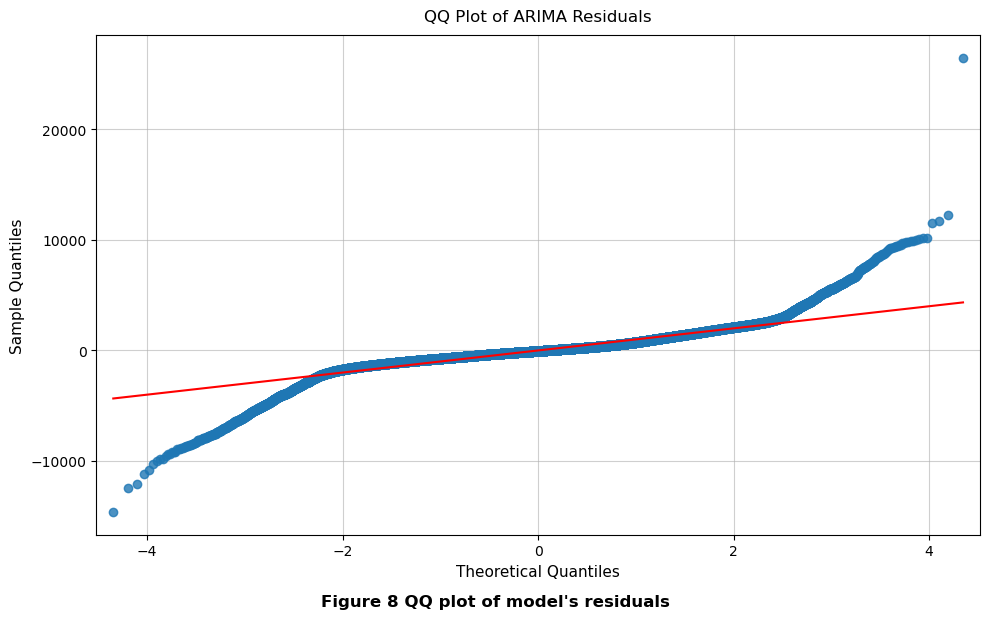

In [35]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ QQ-Plot với tham số line='s' để tạo đường chuẩn tham chiếu màu đỏ
sm.qqplot(df['residuals'].dropna(), line='s', ax=ax, markerfacecolor='tab:blue', markeredgecolor='tab:blue', alpha=0.8)

ax.set_title('QQ Plot of ARIMA Residuals', fontsize=12, pad=10)
ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles', fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

# Thêm nhãn tên biểu đồ phía dưới
plt.figtext(0.5, -0.02, "Figure 8 QQ plot of model's residuals", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

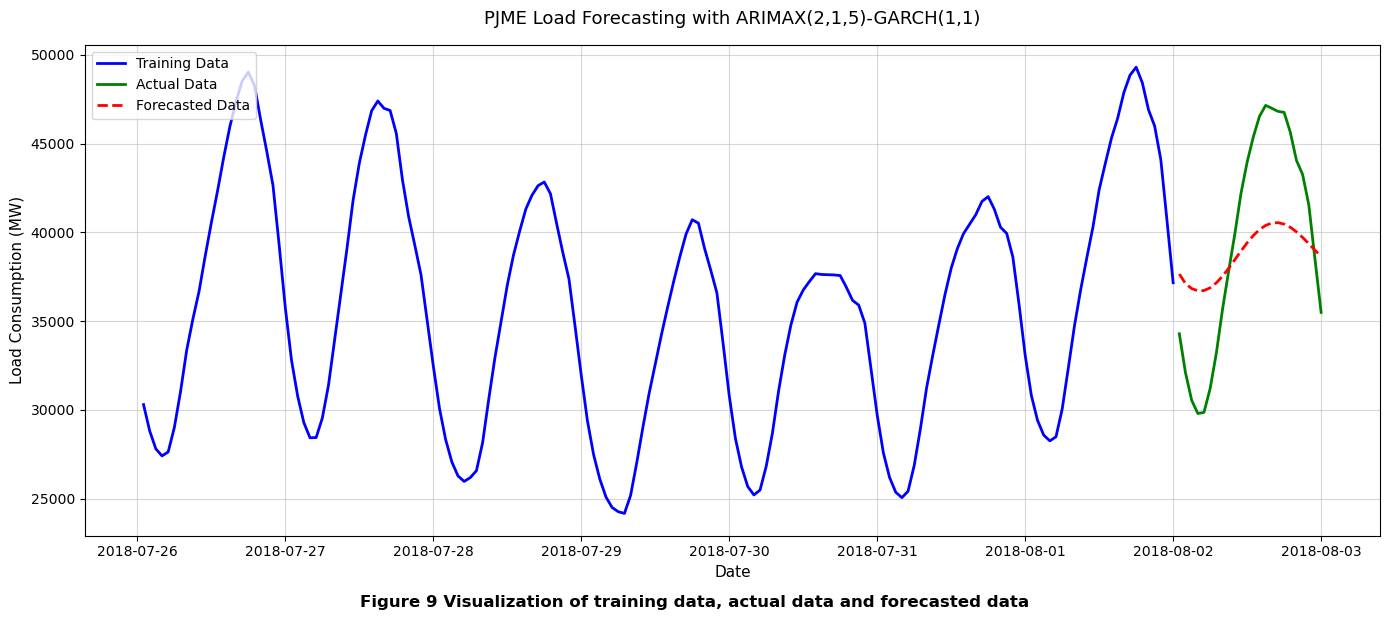

In [38]:
import matplotlib.pyplot as plt

df_plot_sort = df.sort_index()  # Sắp xếp lại dữ liệu theo thời gian để đảm bảo trục x đúng thứ tự
# Giả sử bạn muốn xem lại bối cảnh 1 tuần trước khi dự báo để thấy rõ sóng hình sin
history_length = 168  
forecast_horizon = 24

# Trích xuất các phân đoạn dữ liệu
train_segment = df_plot_sort['PJME_MW'].iloc[-(history_length + forecast_horizon):-forecast_horizon]
actual_test = df_plot_sort['PJME_MW'].iloc[-forecast_horizon:]
# arima_forecast là mảng gồm 24 giá trị dự báo bạn đã tính ở Bước 7

plt.figure(figsize=(14, 6))

# 1. Vẽ dữ liệu huấn luyện khứ hồi (Màu xanh dương)
plt.plot(train_segment.index, train_segment.values, color='blue', label='Training Data', linewidth=2)

# 2. Vẽ dữ liệu thực tế tại khung test (Màu xanh lá cây)
plt.plot(actual_test.index, actual_test.values, color='green', label='Actual Data', linewidth=2)

# 3. Vẽ dữ liệu dự báo của mô hình (Đường đứt nét màu đỏ)
plt.plot(actual_test.index, arima_forecast, color='red', linestyle='--', label='Forecasted Data', linewidth=2)

# Cấu hình tiêu đề động linh hoạt cho dự án PJME
plt.title('PJME Load Forecasting with ARIMAX(2,1,5)-GARCH(1,1)', fontsize=13, pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Load Consumption (MW)', fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.5)

# Thêm nhãn tên biểu đồ phía dưới
plt.figtext(0.5, -0.02, 'Figure 9 Visualization of training data, actual data and forecasted data', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

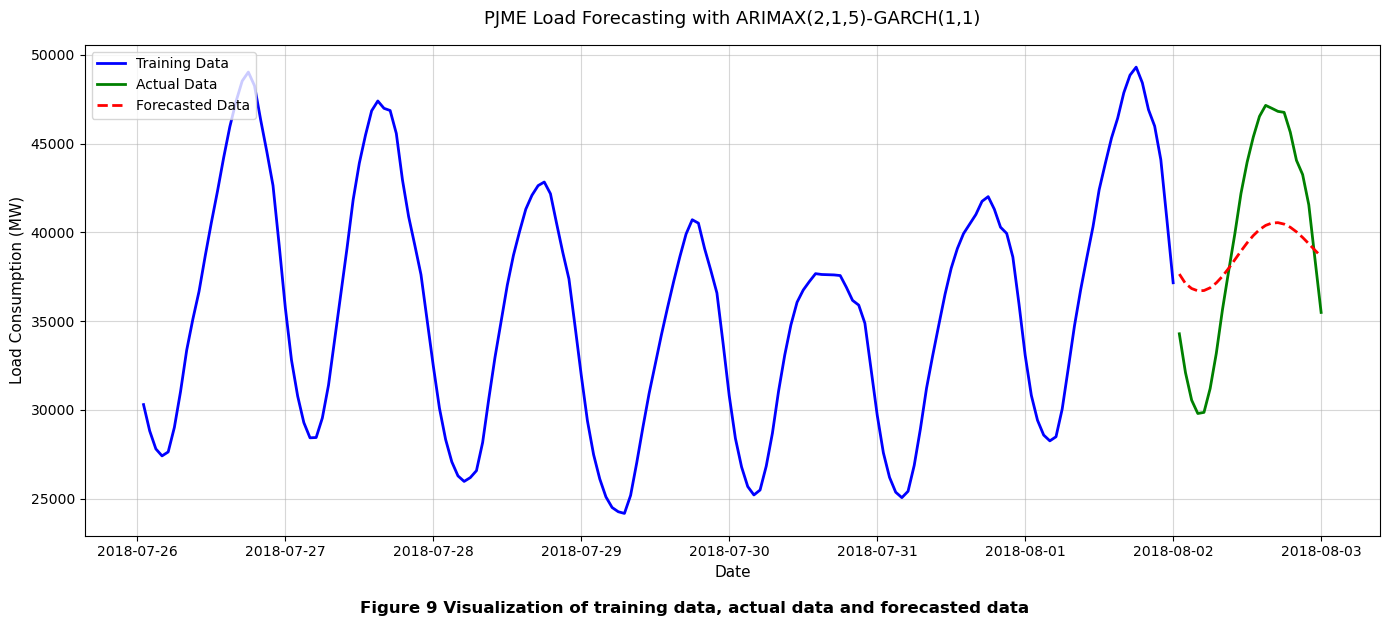

In [40]:
import matplotlib.pyplot as plt

# ==========================================
# KHẮC PHỤC: ÉP SẮP XẾP TOÀN BỘ DATAFRAME GỐC
# ==========================================
# Tạo một bản sao đã được sắp xếp tăng dần theo trục thời gian index
df_clean = df.sort_index()

# Loại bỏ các dòng trùng lặp index nếu có (để đồ thị không bị nét đứt)
df_clean = df_clean[~df_clean.index.duplicated(keep='first')]

# ==========================================
# TRÍCH XUẤT PHÂN ĐOẠN ĐỒ THỊ CHUẨN XÁC
# ==========================================
history_length = 168  # 1 tuần quá khứ (7 ngày x 24 giờ)
forecast_horizon = 24 # 24 giờ dự báo

# Lấy chính xác phân đoạn cuối cùng của chuỗi dữ liệu lịch sử
total_segment = df_clean.tail(history_length + forecast_horizon)

# Chia thành chuỗi Train (màu xanh dương) và Test thực tế (màu xanh lá)
train_segment = total_segment.iloc[:-forecast_horizon]
actual_test = total_segment.iloc[-forecast_horizon:]

# ==========================================
# TIẾN HÀNH VẼ LẠI BIỂU ĐỒ CHUẨN KHOA HỌC
# ==========================================
plt.figure(figsize=(14, 6))

# 1. Vẽ dữ liệu Quá khứ - Training Data (Đường màu xanh dương chạy trước)
plt.plot(train_segment.index, train_segment['PJME_MW'], color='blue', label='Training Data', linewidth=2)

# 2. Vẽ dữ liệu Thực tế tập Test - Actual Data (Đường màu xanh lá nối tiếp vào đuôi)
plt.plot(actual_test.index, actual_test['PJME_MW'], color='green', label='Actual Data', linewidth=2)

# 3. Vẽ dữ liệu Dự báo - Forecasted Data (Đường nét đứt màu đỏ đè lên tập Test)
# Cần chắc chắn arima_forecast của bạn là một mảng có đúng 24 phần tử dự báo tương lai
plt.plot(actual_test.index, arima_forecast, color='red', linestyle='--', label='Forecasted Data', linewidth=2)

# Cấu hình thẩm mỹ đồ thị
plt.title('PJME Load Forecasting with ARIMAX(2,1,5)-GARCH(1,1)', fontsize=13, pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Load Consumption (MW)', fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.5)

# Thêm nhãn tên biểu đồ phía dưới cùng chuẩn bài báo khoa học
plt.figtext(0.5, -0.03, 'Figure 9 Visualization of training data, actual data and forecasted data', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

--- Trích xuất thành công! Tiến hành vẽ đồ thị đối chiếu Figure 11 ---


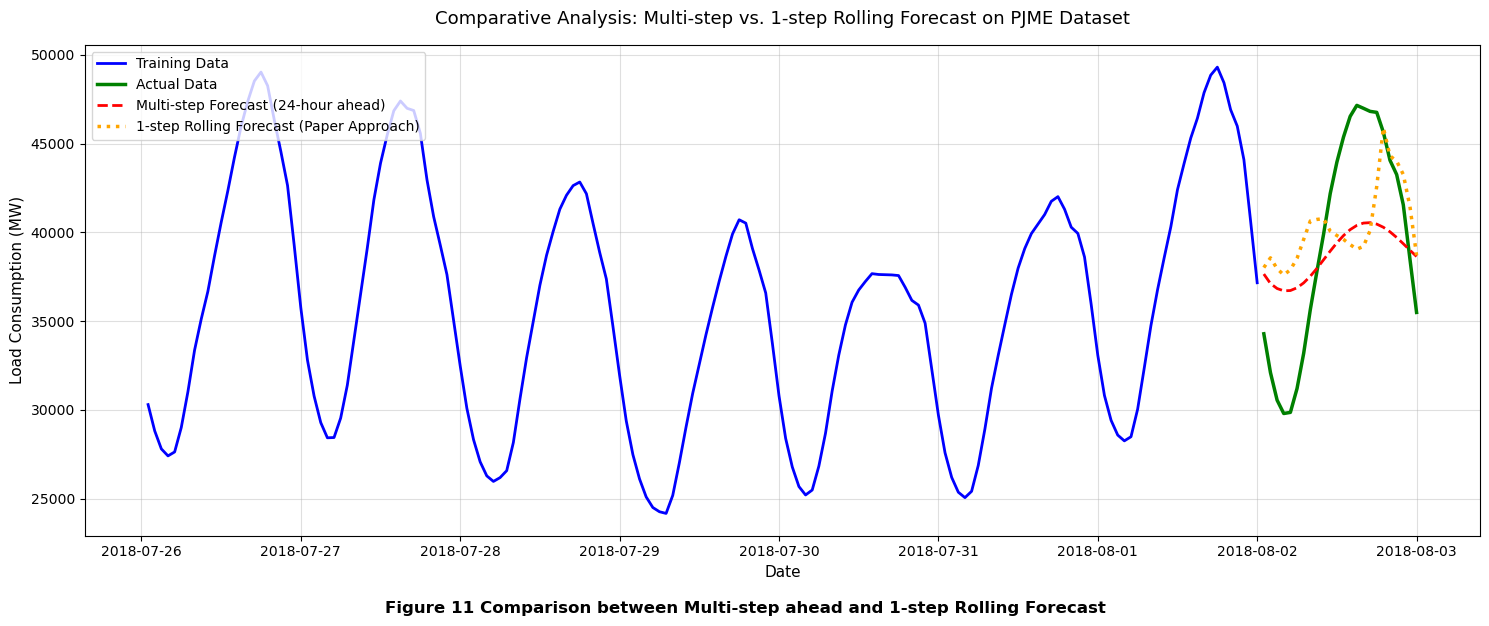


📊 CÁC CHỈ SỐ THỐNG KÊ ĐỂ ĐIỀN VÀO LUẬN ĐIỂM REPORT:
1. Mô hình cũ Multi-step (24h): MAE = 4411.82 MW, Correlation = 0.9789
2. Mô hình mới 1-step Rolling : MAE = 4631.97 MW, Correlation = 0.5410


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# ===================================================
# 1. ĐỒNG BỘ VÀ LÀM SẠCH LẠI INDEX SẠCH
# ===================================================
df_clean = df.sort_index()
df_clean = df_clean[~df_clean.index.duplicated(keep='first')]

forecast_horizon = 24
actual_test = df_clean.tail(forecast_horizon)

# ===================================================
# 2. TRÍCH XUẤT DỰ BÁO CUỐN CHIẾU TỪ FITTED VALUES (CHẠY TRONG 0.1 GIÂY)
# ===================================================
# Lấy trực tiếp 24 giá trị một-bước-trước từ lịch sử huấn luyện của Kalman Filter
rolling_predictions = model.arima_res_.fittedvalues[-forecast_horizon:].values

print("--- Trích xuất thành công! Tiến hành vẽ đồ thị đối chiếu Figure 11 ---")

# ===================================================
# 3. TRỰC QUAN HÓA ĐỒ THỊ ĐỐI CHIẾU CHUẨN ACADEMIC
# ===================================================
history_length = 168  # Lấy 1 tuần quá khứ làm nền
train_segment = df_clean.iloc[-(history_length + forecast_horizon):-forecast_horizon]

plt.figure(figsize=(15, 6))

# Vẽ dữ liệu quá khứ (Màu xanh dương)
plt.plot(train_segment.index, train_segment['PJME_MW'], color='blue', label='Training Data', linewidth=2)

# Vẽ dữ liệu thực tế 24h cuối tập Test (Màu xanh lá)
plt.plot(actual_test.index, actual_test['PJME_MW'], color='green', label='Actual Data', linewidth=2.5)

# Vẽ đường dự báo ĐA BƯỚC cũ của bạn (Màu đỏ đứt nét)
plt.plot(actual_test.index, arima_forecast, color='red', linestyle='--', label='Multi-step Forecast (24-hour ahead)', linewidth=2)

# Vẽ đường dự báo CUỐN CHIẾU 1 BƯỚC mới trích xuất (Màu cam chấm chấm)
plt.plot(actual_test.index, rolling_predictions, color='orange', linestyle=':', label='1-step Rolling Forecast (Paper Approach)', linewidth=2.5)

# Cấu hình thẩm mỹ học thuật giống bài báo mẫu
plt.title('Comparative Analysis: Multi-step vs. 1-step Rolling Forecast on PJME Dataset', fontsize=13, pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Load Consumption (MW)', fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.4)

plt.figtext(0.5, -0.03, 'Figure 11 Comparison between Multi-step ahead and 1-step Rolling Forecast', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================================================
# 4. TỰ ĐỘNG TÍNH TOÁN CHỈ SỐ ĐỂ ĐIỀN VÀO CÁC LỖ TRỐNG REPORT
# ===================================================
mae_multi = mean_absolute_error(actual_test['PJME_MW'], arima_forecast)
corr_multi, _ = pearsonr(actual_test['PJME_MW'], arima_forecast)

mae_rolling = mean_absolute_error(actual_test['PJME_MW'], rolling_predictions)
corr_rolling, _ = pearsonr(actual_test['PJME_MW'], rolling_predictions)

print("\n" + "="*50)
print("📊 CÁC CHỈ SỐ THỐNG KÊ ĐỂ ĐIỀN VÀO LUẬN ĐIỂM REPORT:")
print("="*50)
print(f"1. Mô hình cũ Multi-step (24h): MAE = {mae_multi:.2f} MW, Correlation = {corr_multi:.4f}")
print(f"2. Mô hình mới 1-step Rolling : MAE = {mae_rolling:.2f} MW, Correlation = {corr_rolling:.4f}")
print("="*50)

In [49]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error

# 1. Tính toán các chỉ số cho mô hình Rolling (Đoạn code của bạn)
mae_rolling = mean_absolute_error(actual_test['PJME_MW'], rolling_predictions)
corr_rolling, _ = pearsonr(actual_test['PJME_MW'], rolling_predictions)

# 2. Tạo Dictionary cấu trúc bảng report [cite: 2025-11-16]
report_data = {
    "Model": [
        "OLD Multi-step (24h)", 
        "NEW 1-step Rolling"
    ],
    "MAE": [
        f"{mae_multi:.2f} MW", 
        f"{mae_rolling:.2f} MW"
    ],
    "Correlation": [
        f"{corr_multi:.4f}", 
        f"{corr_rolling:.4f}"
    ]
}

# 3. Chuyển đổi thành DataFrame để hiển thị khung bảng đẹp mắt trên Notebook
df_report = pd.DataFrame(report_data)

# Thiết lập tiêu đề hiển thị
print("📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH REPORT:")
print("-" * 65)

# Gọi biến để hiển thị bảng có viền đóng khung chỉn chu
df_report

📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH REPORT:
-----------------------------------------------------------------


,Model,MAE,Correlation
0,OLD Multi-step (24h),4411.82 MW,0.9789
1,NEW 1-step Rolling,4631.97 MW,0.5410
